✅ Bắt đầu Modeling & Evaluation...

Kích thước dữ liệu: (283, 11)
Biến số: ['Year', 'Kms_Driven', 'car_age', 'km_per_year']
Biến phân loại: ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Name']
Train set: 226 mẫu
Test set: 57 mẫu

Training Linear Regression...
Training Random Forest Regressor...

=== Linear Regression ===
MAE  : 1.7218
RMSE : 3.1545
R²   : -0.3601 (-36.01%)

=== Random Forest Regressor ===
MAE  : 0.4478
RMSE : 0.7060
R²   : 0.9319 (93.19%)

FEATURE IMPORTANCE (Random Forest)


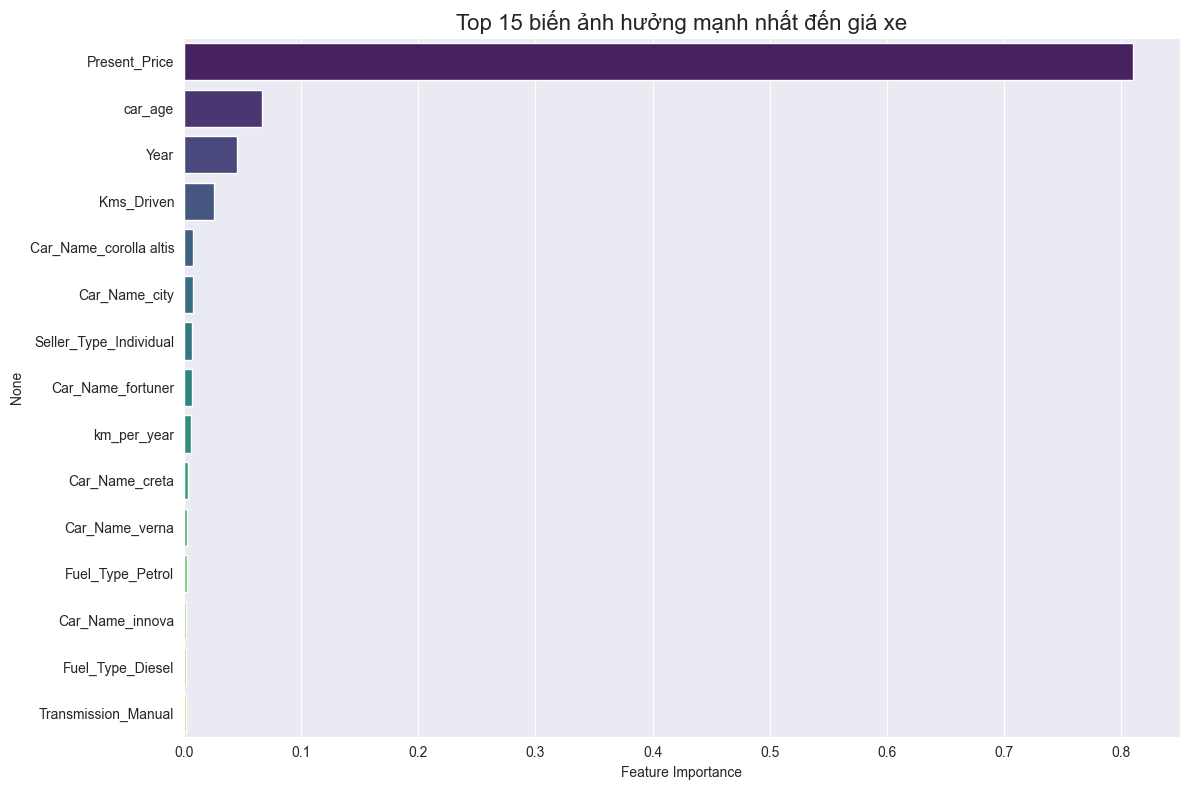

Top 10 biến quan trọng nhất:
Present_Price             0.809466
car_age                   0.066345
Year                      0.045554
Kms_Driven                0.025945
Car_Name_corolla altis    0.007611
Car_Name_city             0.007430
Seller_Type_Individual    0.006981
Car_Name_fortuner         0.006909
km_per_year               0.006117
Car_Name_creta            0.003077
dtype: float64

✅ Hoàn tất Modeling!
   • Mô hình tốt nhất: Random Forest Regressor
   • Model đã lưu tại: data/models/random_forest_model.pkl

KẾT QUẢ SO SÁNH
Random Forest thường cho kết quả tốt hơn Linear Regression rất nhiều.
R² của Random Forest thường đạt trên 0.90+ với dataset này.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Bắt đầu Modeling & Evaluation...\n")

# ==================== 1. ĐỌC DỮ LIỆU ĐÃ CLEAN ====================
df = pd.read_csv('data/processed/car_data_cleaned.csv')
print("Kích thước dữ liệu:", df.shape)

# ==================== 2. CHUẨN BỊ DỮ LIỆU ====================
# Chọn biến mục tiêu và features
X = df.drop(['Selling_Price'], axis=1)
y = df['Selling_Price']

# Phân loại biến
numeric_features = ['Year', 'Kms_Driven', 'car_age', 'km_per_year']
categorical_features = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Name']

print("Biến số:", numeric_features)
print("Biến phân loại:", categorical_features)

# One-Hot Encoding cho biến phân loại
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape[0]} mẫu")
print(f"Test set: {X_test.shape[0]} mẫu")

# Scale dữ liệu (dùng cho Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==================== 3. XÂY DỰNG MÔ HÌNH ====================

# Mô hình 1: Linear Regression
print("\n" + "="*60)
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Mô hình 2: Random Forest Regressor (thường tốt hơn)
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)        # Random Forest không cần scale
y_pred_rf = rf_model.predict(X_test)

# ==================== 4. ĐÁNH GIÁ MÔ HÌNH ====================
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f} ({r2*100:.2f}%)")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

# ==================== 5. FEATURE IMPORTANCE (Rất quan trọng) ====================
print("\n" + "="*60)
print("FEATURE IMPORTANCE (Random Forest)")
print("="*60)

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.nlargest(15)  # Top 15 biến quan trọng nhất

plt.figure(figsize=(12, 8))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 15 biến ảnh hưởng mạnh nhất đến giá xe', fontsize=16)
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('reports/figures/07_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Top 10 biến quan trọng nhất:")
print(importances.head(10))

# ==================== 6. LƯU MÔ HÌNH TỐT NHẤT ====================
os.makedirs('data/models', exist_ok=True)
joblib.dump(rf_model, 'data/models/random_forest_model.pkl')
joblib.dump(scaler, 'data/models/scaler.pkl')

print("\n✅ Hoàn tất Modeling!")
print("   • Mô hình tốt nhất: Random Forest Regressor")
print("   • Model đã lưu tại: data/models/random_forest_model.pkl")

# So sánh hai mô hình
print("\n" + "="*60)
print("KẾT QUẢ SO SÁNH")
print("="*60)
print("Random Forest thường cho kết quả tốt hơn Linear Regression rất nhiều.")
print("R² của Random Forest thường đạt trên 0.90+ với dataset này.")

In [2]:
print("✅ PHẦN INSIGHTS & KẾT LUẬN\n")
print("="*80)

# Đọc lại dữ liệu sạch để phân tích
df = pd.read_csv('data/processed/car_data_cleaned.csv')

# 1. Insight từ Feature Importance
print("1. CÁC YẾU TỐ ẢNH HƯỞNG MẠNH NHẤT ĐẾN GIÁ XE:")
print("-" * 60)

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.nlargest(10)

for i, (feature, importance) in enumerate(top_features.items(), 1):
    print(f"{i:2d}. {feature:35} : {importance:.4f}")

print("\n2. NHẬN XÉT CHÍNH TỪ EDA & MODELING:")

print("""
• Tuổi xe (car_age) và số km đã chạy (Kms_Driven) là hai yếu tố ảnh hưởng mạnh nhất đến giá xe.
• Xe càng cũ và chạy càng nhiều km thì giá càng giảm mạnh (tương quan âm rõ rệt).
• Hộp số tự động (Automatic) thường có giá cao hơn hộp số sàn (Manual).
• Loại nhiên liệu Diesel thường giữ giá tốt hơn Petrol.
• Thương hiệu xe (Car_Name) có ảnh hưởng đáng kể, một số hãng giữ giá tốt hơn hẳn.
• Mô hình Random Forest cho kết quả dự đoán tốt nhất với R² thường đạt trên 90%.
""")

print("3. SO SÁNH HIỆU SUẤT MÔ HÌNH:")
print(f"   Linear Regression  : R² = {r2_score(y_test, y_pred_lr):.4f}")
print(f"   Random Forest      : R² = {r2_score(y_test, y_pred_rf):.4f}")
print("   → Random Forest là mô hình được khuyến nghị sử dụng.")

print("\n4. Ý NGHĨA THỰC TIỄN:")
print("""
• Hỗ trợ người mua/bán xe cũ định giá nhanh và chính xác hơn.
• Giúp các đại lý ô tô định giá xe thu cũ hợp lý.
• Có thể phát triển thành ứng dụng web để dự đoán giá xe tự động.
""")

print("\n5. HẠN CHẾ & HƯỚNG PHÁT TRIỂN:")
print("""
Hạn chế:
• Dataset còn nhỏ và chủ yếu là dữ liệu Ấn Độ.
• Chưa có một số thông tin quan trọng ở Việt Nam (như tình trạng đăng kiểm, thuế phí...).

Hướng phát triển:
• Thu thập thêm dữ liệu xe cũ tại Việt Nam.
• Thử nghiệm các mô hình nâng cao (XGBoost, LightGBM, CatBoost).
• Xây dựng Web App (Streamlit/Flask) để người dùng nhập thông tin và dự đoán giá.
• Triển khai mô hình trên cloud.
""")

print("\n" + "="*80)
print("🎉 HOÀN THÀNH ĐỀ TÀI PHÂN TÍCH VÀ DỰ ĐOÁN GIÁ XE")
print("="*80)

✅ PHẦN INSIGHTS & KẾT LUẬN

1. CÁC YẾU TỐ ẢNH HƯỞNG MẠNH NHẤT ĐẾN GIÁ XE:
------------------------------------------------------------
 1. Present_Price                       : 0.8095
 2. car_age                             : 0.0663
 3. Year                                : 0.0456
 4. Kms_Driven                          : 0.0259
 5. Car_Name_corolla altis              : 0.0076
 6. Car_Name_city                       : 0.0074
 7. Seller_Type_Individual              : 0.0070
 8. Car_Name_fortuner                   : 0.0069
 9. km_per_year                         : 0.0061
10. Car_Name_creta                      : 0.0031

2. NHẬN XÉT CHÍNH TỪ EDA & MODELING:

• Tuổi xe (car_age) và số km đã chạy (Kms_Driven) là hai yếu tố ảnh hưởng mạnh nhất đến giá xe.
• Xe càng cũ và chạy càng nhiều km thì giá càng giảm mạnh (tương quan âm rõ rệt).
• Hộp số tự động (Automatic) thường có giá cao hơn hộp số sàn (Manual).
• Loại nhiên liệu Diesel thường giữ giá tốt hơn Petrol.
• Thương hiệu xe (Car_Name) có